In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot

from sklearn.datasets import load_iris
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

In [14]:
# load data
iris = load_iris()
X = iris.data
X = StandardScaler().fit_transform(X)

#### **TruncatedSVD() from sklearn:**

In [16]:
# Using TruncatedSVD(sklearn)
svd = TruncatedSVD(n_components=2, random_state=42)
X_reducted = svd.fit_transform(X)

/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)


In [24]:
print(f'Top variances: {svd.explained_variance_}')
print(f'Explained variance ratio: {svd.explained_variance_ratio_}')
print(f'Cumulative Explained variance: {svd.explained_variance_ratio_.sum()}')

Top variances: [2.91849782 0.91403047]
Explained variance ratio: [0.72962445 0.22850762]
Cumulative Explained variance: 0.9581320720000164


#### **Manually Calculate**

In [25]:
U, S, VT = np.linalg.svd(X)

In [34]:
X_reduced = U[:, :2] * S[:2]
X_reduced[:5]

array([[-2.26470281, -0.4800266 ],
       [-2.08096115,  0.67413356],
       [-2.36422905,  0.34190802],
       [-2.29938422,  0.59739451],
       [-2.38984217, -0.64683538]])

In [38]:
print(f'Singular values (already sorted): {S}')
print(f'Top 2 explained variance: {S[:2]**2 / (S**2).sum()}')

Singular values (already sorted): [20.92306556 11.7091661   4.69185798  1.76273239]
Top 2 explained variance: [0.72962445 0.22850762]


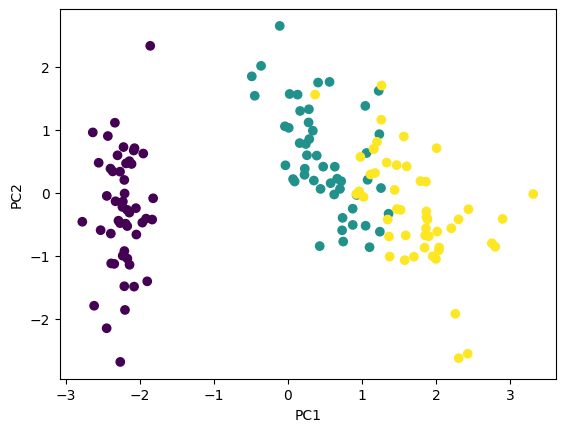

In [36]:
import matplotlib.pyplot as plt

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=iris.target, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()